In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce GTX 1650


In [2]:

# ─────────────────────────────────────────────
# SECTION 0: Imports
# ─────────────────────────────────────────────
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


In [3]:
 
df = pd.read_csv("Combined Data/Combined_dataset.csv")
 

In [4]:
print("Shape:", df.shape)
df.head()
df.info()
 

Shape: (2827977, 14)
<class 'pandas.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           str    
 1   Area                              str    
 2   Waterbody Type                    str    
 3   Date                              str    
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          str    
dtypes: float64(9), str(5)
memory usage: 302.1 MB


In [5]:
df.isnull().sum()

Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

In [6]:
df["CCME_Values"].describe()


count    2.827977e+06
mean     8.504668e+01
std      1.764665e+01
min      3.130414e+01
25%      7.715349e+01
50%      9.059609e+01
75%      1.000000e+02
max      1.000000e+02
Name: CCME_Values, dtype: float64

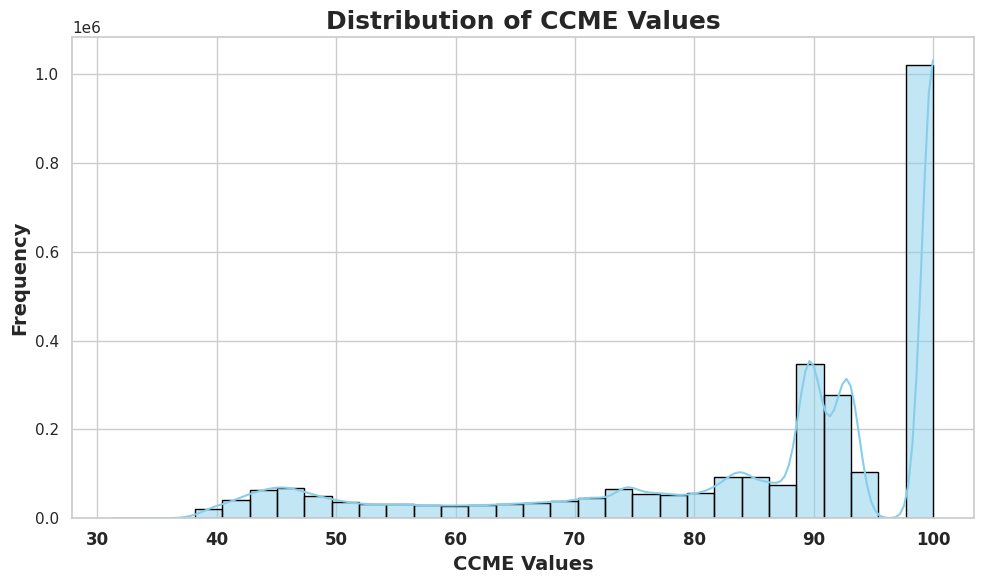

In [7]:

plt.figure(figsize=(10, 6))
sns.histplot(df["CCME_Values"].dropna(), bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of CCME Values", fontsize=18, fontweight="bold")
plt.xlabel("CCME Values", fontsize=14, fontweight="bold")
plt.ylabel("Frequency", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



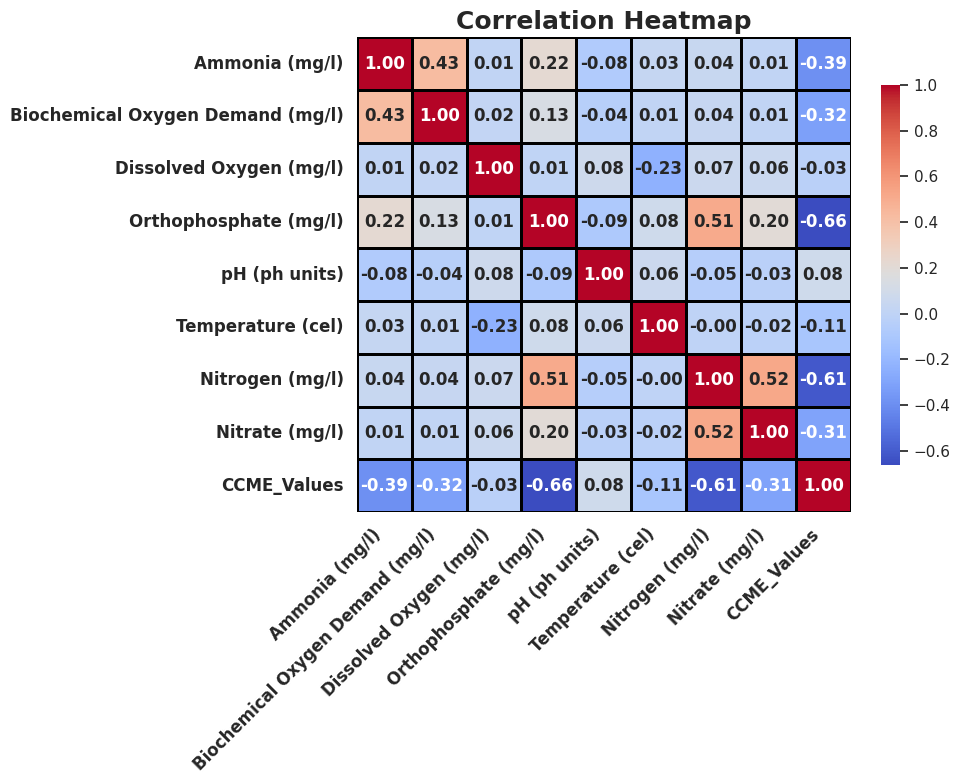

In [8]:
 
# --- Correlation Heatmap ---
corr_data = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f",
                 annot_kws={"size": 12, "weight": "bold"},
                 linewidths=1, linecolor="black", cbar_kws={"shrink": 0.8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight="bold",
                   rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight="bold")
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.tight_layout(); plt.show()


In [9]:
# ─────────────────────────────────────────────
# SECTION 2: Cleaning & Feature Engineering
# ─────────────────────────────────────────────
df["Date"]        = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["CCME_Values"] = pd.to_numeric(df["CCME_Values"], errors="coerce")
df["Year"]        = df["Date"].dt.year
df["Month"]       = df["Date"].dt.month

# --- Valid ranges filter ---
valid_ranges = {
    "Ammonia (mg/l)": (0, 20),
    "Biochemical Oxygen Demand (mg/l)": (0, 50),
    "Dissolved Oxygen (mg/l)": (2, 30),
    "Orthophosphate (mg/l)": (0, 10),
    "pH (ph units)": (4, 11),
    "Temperature (cel)": (0, 60),
    "Nitrogen (mg/l)": (0, 50),
    "Nitrate (mg/l)": (0, 100),
    "CCME_Values": (0, 100)
}
mask_valid = pd.Series(True, index=df.index)
for col, (low, high) in valid_ranges.items():
    mask_valid &= df[col].between(low, high, inclusive="both")

df_clean = df[mask_valid].copy().drop_duplicates()
print(f"After cleaning: {df_clean.shape[0]} rows")


After cleaning: 2724675 rows


In [10]:
# --- Waterbody Type grouping ---
df_clean['Waterbody Type'] = df_clean['Waterbody Type'].replace({
    'Marine': 'Coastal/Marine', 'Sea Water': 'Coastal/Marine',
    'Coastal': 'Coastal/Marine', 'Estuarine': 'Coastal/Marine',
    'Sewage': 'Wastewater', 'Effluent': 'Wastewater',
    'Canal': 'Artificial', 'Drainage': 'Artificial',
    'Bay': 'Minor Waterbodies', 'Artificial': 'Minor Waterbodies',
    'Transitional': 'Minor Waterbodies'
})

# ── NEW: Sin/Cos encoding للشهر (Seasonality Awareness) ──────────────────
df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)

df_encoded = pd.get_dummies(df_clean, columns=['Waterbody Type'], dtype="int")
print("Columns after encoding:", df_encoded.shape[1])



Columns after encoding: 23


In [11]:
# ─────────────────────────────────────────────
# SECTION 3: Train / Val / Test Split (Area-wise)
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df_encoded['Date'] = pd.to_datetime(df_encoded['Date'], dayfirst=True, errors='coerce')
df_encoded = df_encoded.sort_values(by=['Area', 'Date']).reset_index(drop=True)

unique_areas = df_encoded['Area'].unique()
np.random.seed(42)
np.random.shuffle(unique_areas)

train_size = int(len(unique_areas) * 0.70)
val_size   = int(len(unique_areas) * 0.15)

train_areas = unique_areas[:train_size]
val_areas   = unique_areas[train_size:train_size + val_size]
test_areas  = unique_areas[train_size + val_size:]

df_train_final = df_encoded[df_encoded['Area'].isin(train_areas)].copy()
df_val_final   = df_encoded[df_encoded['Area'].isin(val_areas)].copy()
df_test_final  = df_encoded[df_encoded['Area'].isin(test_areas)].copy()

print(f"Train: {len(df_train_final)} | Val: {len(df_val_final)} | Test: {len(df_test_final)}")


Using device: cuda
Train: 1931177 | Val: 390568 | Test: 402930


In [12]:
# ─────────────────────────────────────────────
# SECTION 4: Preprocessing
# ─────────────────────────────────────────────
DROP_COLS = ["CCME_WQI", "Country", "Area", "Date", "Year", "CCME_Values", "Month"]

def extract_X_y(df):
    X_df = df.drop(columns=DROP_COLS, errors='ignore')
    y_df = df["CCME_Values"].values.astype(np.float32)
    return X_df, y_df

X_train, y_train = extract_X_y(df_train_final)
X_val,   y_val   = extract_X_y(df_val_final)
X_test,  y_test  = extract_X_y(df_test_final)

# Clean column names
def clean_cols(df):
    df.columns = [c.replace(' ', '_').replace('/', '_')
                   .replace('(', '').replace(')', '') for c in df.columns]
    return df

X_train = clean_cols(X_train)
X_val   = clean_cols(X_val)
X_test  = clean_cols(X_test)

# ✅ FIX: Use reindex to safely align columns with train set.
# This handles cases where val/test splits are missing certain one-hot
# categories that exist in train (fills missing columns with 0).
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train columns : {X_train.shape[1]}")
print(f"Val   columns : {X_val.shape[1]}  (aligned to train)")
print(f"Test  columns : {X_test.shape[1]}  (aligned to train)")

num_features = [
    "Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
    "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel",
    "Nitrogen_mg_l", "Nitrate_mg_l"
]
cat_features = [c for c in X_train.columns if c not in num_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('pw', PowerTransformer(method='yeo-johnson')),
        ('sc', StandardScaler())
    ]), num_features),
    ('cat', 'passthrough', cat_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print(f"Feature dim after preprocessing: {X_train.shape[1]}")
print(f"Feature dim after preprocessing: {X_train_proc.shape[1]}")


Train columns : 16
Val   columns : 16  (aligned to train)
Test  columns : 16  (aligned to train)
Feature dim after preprocessing: 16
Feature dim after preprocessing: 16


In [13]:
# ─────────────────────────────────────────────
# SECTION 5: Sliding Window Sequences
# ─────────────────────────────────────────────
SEQ_LEN = 8

def create_sequences(X_proc, y_data, areas_df, seq_length=8, stride=3):
    all_x, all_y = [], []
    areas_vals = areas_df['Area'].values
    y_vals     = y_data.values if hasattr(y_data, 'values') else y_data

    for area in tqdm(areas_df['Area'].unique(), desc="Windowing", unit="area"):
        mask    = (areas_vals == area)
        X_area  = X_proc[mask]
        y_area  = y_vals[mask]
        if len(X_area) > seq_length:
            for start in range(0, len(X_area) - seq_length + 1, stride):
                all_x.append(X_area[start:start + seq_length])
                all_y.append(y_area[start + seq_length - 1])

    return np.array(all_x, dtype=np.float32), np.array(all_y, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences(X_train_proc, y_train, df_train_final,
                                             seq_length=SEQ_LEN, stride=4)
X_val_seq,   y_val_seq   = create_sequences(X_val_proc,   y_val,   df_val_final,
                                             seq_length=SEQ_LEN, stride=1)
X_test_seq,  y_test_seq  = create_sequences(X_test_proc,  y_test,  df_test_final,
                                             seq_length=SEQ_LEN, stride=1)

print(f"Train seq: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")


# ── Save sequences to disk ──
import joblib
joblib.dump(
    (X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq),
    "sequences.pkl"
)
print("[✔] sequences.pkl saved.")


Windowing: 100%|██████████| 9005/9005 [04:54<00:00, 30.62area/s]


Train seq: (440536, 8, 16) | Val: (348027, 8, 16) | Test: (359950, 8, 16)
[✔] sequences.pkl saved.


In [14]:
import joblib

 
X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = joblib.load("sequences.pkl")

In [15]:

X_train_t = torch.FloatTensor(X_train_seq)                        # CPU – DataLoader transfers each batch
y_train_t = torch.FloatTensor(y_train_seq).unsqueeze(1)           # CPU

X_val_t   = torch.FloatTensor(X_val_seq).to(device)               # GPU – used directly
y_val_t   = torch.FloatTensor(y_val_seq).unsqueeze(1).to(device)  # GPU

X_test_t  = torch.FloatTensor(X_test_seq).to(device)              # GPU – used directly
y_test_t  = torch.FloatTensor(y_test_seq).unsqueeze(1).to(device) # GPU

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           pin_memory=(device.type == 'cuda'),     
                           num_workers=0)
val_loader    = DataLoader(TensorDataset(X_val_t, y_val_t),   batch_size=64, shuffle=False)
test_loader   = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Loaders ready.")
print(f"  Train batches : {len(train_loader)} | X_train_t device: {X_train_t.device}")
print(f"  Val   batches : {len(val_loader)}   | X_val_t   device: {X_val_t.device}")
print(f"  Test  batches : {len(test_loader)}  | X_test_t  device: {X_test_t.device}")


Loaders ready.
  Train batches : 6884 | X_train_t device: cpu
  Val   batches : 5438   | X_val_t   device: cuda:0
  Test  batches : 5625  | X_test_t  device: cuda:0


In [16]:
# ─────────────────────────────────────────────
# SECTION 7: Model Architecture
#   Dual-Branch Cross-Attention Transformer
# ─────────────────────────────────────────────

class FeatureEmbedding(nn.Module):
    """Projects each scalar feature to a d_model-dim vector."""
    def __init__(self, num_features, d_model):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Linear(1, d_model) for _ in range(num_features)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, T, F]
        B, T, F = x.shape
        embedded = []
        for i, emb in enumerate(self.embeddings):
            embedded.append(emb(x[:, :, i:i+1]))   # [B, T, d_model]
        out = torch.stack(embedded, dim=2)           # [B, T, F, d_model]
        return self.norm(out)


class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


In [17]:
# ── Branch 1: Feature Transformer ────────────────────────────────────────
class FeatureTransformer(nn.Module):
    """
    Self-Attention across features at every time step.
    Captures chemical relationships: how Ammonia affects pH, etc.
    Input:  [B, T, F, d_model]
    Output: [B, T, d_model]
    """
    def __init__(self, d_model, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm     = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, T, F, d_model]
        B, T, F, D = x.shape
        x_flat = x.view(B * T, F, D)         # treat time as batch
        out    = self.encoder(x_flat)         # [B*T, F, D]
        out    = out.mean(dim=1)              # pool over features → [B*T, D]
        out    = out.view(B, T, D)            # [B, T, D]
        return self.norm(out)


In [18]:
# ── Branch 2: Temporal Transformer ───────────────────────────────────────
class TemporalTransformer(nn.Module):
    """
    Self-Attention across time steps.
    Captures temporal evolution: gradual quality degradation, seasonal trends.
    Input:  [B, T, input_dim]
    Output: [B, T, d_model]
    """
    def __init__(self, input_dim, d_model, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.proj    = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm     = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, T, input_dim]
        x = self.proj(x)           # [B, T, d_model]
        x = self.pos_enc(x)
        x = self.encoder(x)        # [B, T, d_model]
        return self.norm(x)


In [19]:
# ── Fusion: Cross-Attention ───────────────────────────────────────────────
class CrossAttentionFusion(nn.Module):
    """
    Feature branch  → Query
    Temporal branch → Key, Value
    Attention(Q,K,V) = softmax(QK^T / sqrt(dk)) V
    Learns WHICH feature was MOST INFLUENTIAL at WHICH time step.
    """
    def __init__(self, d_model, n_heads=4, dropout=0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, feat_out, temp_out):
        # feat_out: [B, T, D]  → Query
        # temp_out: [B, T, D]  → Key & Value
        attn_out, attn_weights = self.cross_attn(
            query=feat_out, key=temp_out, value=temp_out
        )
        fused = self.norm(feat_out + self.dropout(attn_out))
        return fused, attn_weights   # attn_weights: [B, T, T]

In [20]:

# ── Full Model ────────────────────────────────────────────────────────────
class DualBranchWQTransformer(nn.Module):
    """
    Dual-Branch Cross-Attention Transformer for Water Quality Regression.

    Predicts CCME_Values (continuous 0-100) from water quality parameters.

    Architecture:
        Input ──┬── FeatureTransformer  (Q) ──┐
                │                              ├── CrossAttention → Pool → Regress
                └── TemporalTransformer (K,V) ─┘
    """
    def __init__(self, input_dim, d_model=128, n_heads=4,
                 feat_layers=2, temp_layers=2,
                 output_dim=1, dropout=0.15):
        super().__init__()
        self.input_dim = input_dim
        self.d_model   = d_model

        # Branch 1 – Feature Transformer
        self.feat_embed       = FeatureEmbedding(input_dim, d_model)
        self.feat_transformer = FeatureTransformer(d_model, n_heads,
                                                   feat_layers, dropout)

        # Branch 2 – Temporal Transformer
        self.temp_transformer = TemporalTransformer(input_dim, d_model,
                                                    n_heads, temp_layers, dropout)

        # Fusion
        self.cross_attn = CrossAttentionFusion(d_model, n_heads, dropout)

        # Regression head – outputs a single continuous value (CCME score)
        self.pool       = nn.AdaptiveAvgPool1d(1)
        self.regressor  = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(d_model // 2, output_dim)   # scalar output
        )

        # Store attention weights for XAI
        self.last_attn_weights = None

    def forward(self, x):
        # x: [B, T, F]

        # Branch 1: Feature relationships
        feat_emb = self.feat_embed(x)                  # [B, T, F, D]
        feat_out = self.feat_transformer(feat_emb)     # [B, T, D]

        # Branch 2: Temporal dynamics
        temp_out = self.temp_transformer(x)            # [B, T, D]

        # Cross-Attention Fusion
        fused, attn_w = self.cross_attn(feat_out, temp_out)  # [B, T, D]
        self.last_attn_weights = attn_w.detach()

        # Global pool + regress
        fused   = fused.transpose(1, 2)                # [B, D, T]
        pooled  = self.pool(fused).squeeze(-1)         # [B, D]
        out     = self.regressor(pooled)               # [B, 1]
        return out


input_size = X_train_seq.shape[2]
output_dim = 1

model = DualBranchWQTransformer(
    input_dim=input_size,
    d_model=256,       # ↑ زيادة السعة من 128 إلى 256
    n_heads=8,         # ↑ زيادة رؤوس الانتباه
    feat_layers=3,     # ↑ طبقات إضافية
    temp_layers=3,     # ↑ طبقات إضافية
    output_dim=1,
    dropout=0.10       # ↓ تقليل dropout لتحسين التعلم
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"\nModel Parameters: {num_params:,}")
print(f"Task: Regression → predicting CCME_Values (0-100 continuous)")



Model Parameters: 5,115,649
Task: Regression → predicting CCME_Values (0-100 continuous)


In [21]:
# ─────────────────────────────────────────────
# SECTION 8: Training Setup
# ─────────────────────────────────────────────

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=5e-5
)

# Learning rate scheduler (OneCycleLR)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=100,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

# Training hyperparameters
NUM_EPOCHS    = 100
PATIENCE      = 6
MIN_DELTA     = 0.01
GRADIENT_CLIP = 1.0

print(f"Criterion    : {criterion.__class__.__name__}")
print(f"Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)")
print(f"Scheduler    : OneCycleLR  (max_lr=1e-3, epochs={NUM_EPOCHS})")
print(f"Early Stop   : patience={PATIENCE}, min_delta={MIN_DELTA}")
print(f"Gradient Clip: {GRADIENT_CLIP}")


Criterion    : MSELoss
Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)
Scheduler    : OneCycleLR  (max_lr=1e-3, epochs=100)
Early Stop   : patience=6, min_delta=0.01
Gradient Clip: 1.0


In [22]:
# ─────────────────────────────────────────────
# SECTION 8b: Checkpoint Utilities
# ─────────────────────────────────────────────
import os

CHECKPOINT_DIR  = "./checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, scheduler,
                    best_val_loss, path=CHECKPOINT_PATH,
                    train_losses=None, val_losses=None, learning_rates=None):
    """
    Save a full training checkpoint.
    Includes model weights, optimizer state, scheduler state,
    current epoch, best validation score, AND training history lists.
    Uses atomic write (tmp → rename) to avoid corruption on long runs.
    """
    tmp_path   = path + ".tmp"
    checkpoint = {
        "epoch":           epoch,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler else None,
        "best_val_loss":   best_val_loss,
        # ── Training history (for learning curves) ──
        "train_losses":    train_losses   if train_losses   is not None else [],
        "val_losses":      val_losses     if val_losses     is not None else [],
        "learning_rates":  learning_rates if learning_rates is not None else [],
    }
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)   # atomic: prevents corrupt files on crash


def load_checkpoint(path, model, optimizer, scheduler=None):
    """
    Load checkpoint and restore all training state including history lists.
    Returns (start_epoch, best_val_loss, train_losses, val_losses, learning_rates).
    If checkpoint does not exist → returns defaults to start fresh.
    """
    if not os.path.exists(path):
        print("[Checkpoint] No checkpoint found – starting from scratch.")
        return 0, float('inf'), [], [], []

    print(f"[Checkpoint] Resuming from: {path}")
    ckpt = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
        print("[Checkpoint] Scheduler state restored.")

    start_epoch    = ckpt["epoch"] + 1       # resume AFTER the saved epoch
    best_val_loss  = ckpt["best_val_loss"]
    train_losses   = ckpt.get("train_losses",   [])
    val_losses     = ckpt.get("val_losses",     [])
    learning_rates = ckpt.get("learning_rates", [])

    print(f"[Checkpoint] Resumed at epoch {start_epoch} | "
          f"Best Val MSE so far: {best_val_loss:.4f} | "
          f"History loaded: {len(train_losses)} epochs")
    return start_epoch, best_val_loss, train_losses, val_losses, learning_rates


print("[Checkpoint] Utilities ready.")
print(f"  Latest checkpoint : {CHECKPOINT_PATH}")
print(f"  Best model        : {BEST_MODEL_PATH}")


[Checkpoint] Utilities ready.
  Latest checkpoint : ./checkpoints/checkpoint_latest.pth
  Best model        : ./checkpoints/best_model.pth


In [23]:
# ─────────────────────────────────────────────
# SECTION 9: Training Loop (Regression)
# ─────────────────────────────────────────────

start_epoch, best_val_loss, train_losses, val_losses, learning_rates = load_checkpoint(
    CHECKPOINT_PATH, model, optimizer, scheduler
)
patience_counter = 0
best_model_state = None

print("\n" + "="*80)
print(f"{'Epoch':<8}|{'Train Loss (MSE)':<18}|{'Val Loss (MSE)':<18}|{'LR':<10}")
print("-" * 80)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    tr_loss, tr_total = 0.0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch_x, batch_y in loop:
         
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        tr_loss  += loss.item() * batch_y.size(0)
        tr_total += batch_y.size(0)
        loop.set_postfix({'loss': f'{loss.item():.4f}'})
        scheduler.step()

    tr_loss /= tr_total
    train_losses.append(tr_loss)

    model.eval()
    v_loss, v_total = 0.0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # val tensors already on device — no .to(device) needed
            logits = model(batch_x)
            loss   = criterion(logits, batch_y)
            v_loss += loss.item() * batch_y.size(0)
            v_total += batch_y.size(0)

    v_loss /= v_total
    val_losses.append(v_loss)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    print(f"{epoch+1:<8}|{tr_loss:<18.4f}|{v_loss:<18.4f}|{current_lr:<10.6f}")

    # ── Save latest checkpoint WITH full history ──
    save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                    path=CHECKPOINT_PATH,
                    train_losses=train_losses,
                    val_losses=val_losses,
                    learning_rates=learning_rates)

    if v_loss < best_val_loss - MIN_DELTA:
        best_val_loss = v_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                        path=BEST_MODEL_PATH,
                        train_losses=train_losses,
                        val_losses=val_losses,
                        learning_rates=learning_rates)
        print(f"   ✔ Best model saved! (Val Loss: {v_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch+1}")
            break

print("="*80)
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
checkpoint = torch.load(BEST_MODEL_PATH, weights_only=False)
model.load_state_dict(checkpoint["model_state"])


[Checkpoint] Resuming from: ./checkpoints/checkpoint_latest.pth
[Checkpoint] Scheduler state restored.
[Checkpoint] Resumed at epoch 87 | Best Val MSE so far: 0.5756 | History loaded: 87 epochs

Epoch   |Train Loss (MSE)  |Val Loss (MSE)    |LR        
--------------------------------------------------------------------------------


88      |5.2727            |2.3251            |0.000894  


89      |5.1245            |2.2092            |0.000883  


90      |5.0897            |2.3153            |0.000871  


91      |4.9543            |2.0714            |0.000860  


92      |4.9517            |1.9751            |0.000847  


93      |4.9165            |1.9656            |0.000834  

⚡ Early stopping at epoch 93
Best Val Loss: 0.5756
Total epochs trained: 93


<All keys matched successfully>

In [24]:

# ─────────────────────────────────────────────
# SECTION 10: Test Evaluation
# ─────────────────────────────────────────────
model.eval()
t_loss, t_total = 0.0, 0
t_preds, t_targets = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out    = model(batch_x)
        loss   = criterion(out, batch_y)
        t_loss += loss.item() * batch_y.size(0)
        
        t_total += batch_y.size(0)
        t_preds.extend(out.cpu().numpy().flatten())
        t_targets.extend(batch_y.cpu().numpy().flatten())

t_preds = np.array(t_preds)
t_targets = np.array(t_targets)

test_mse = mean_squared_error(t_targets, t_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(t_targets, t_preds)
test_r2 = r2_score(t_targets, t_preds)

print(f"\nTest MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R2:   {test_r2:.4f}")




Test MSE:  0.5411
Test RMSE: 0.7356
Test MAE:  0.3592
Test R2:   0.9980


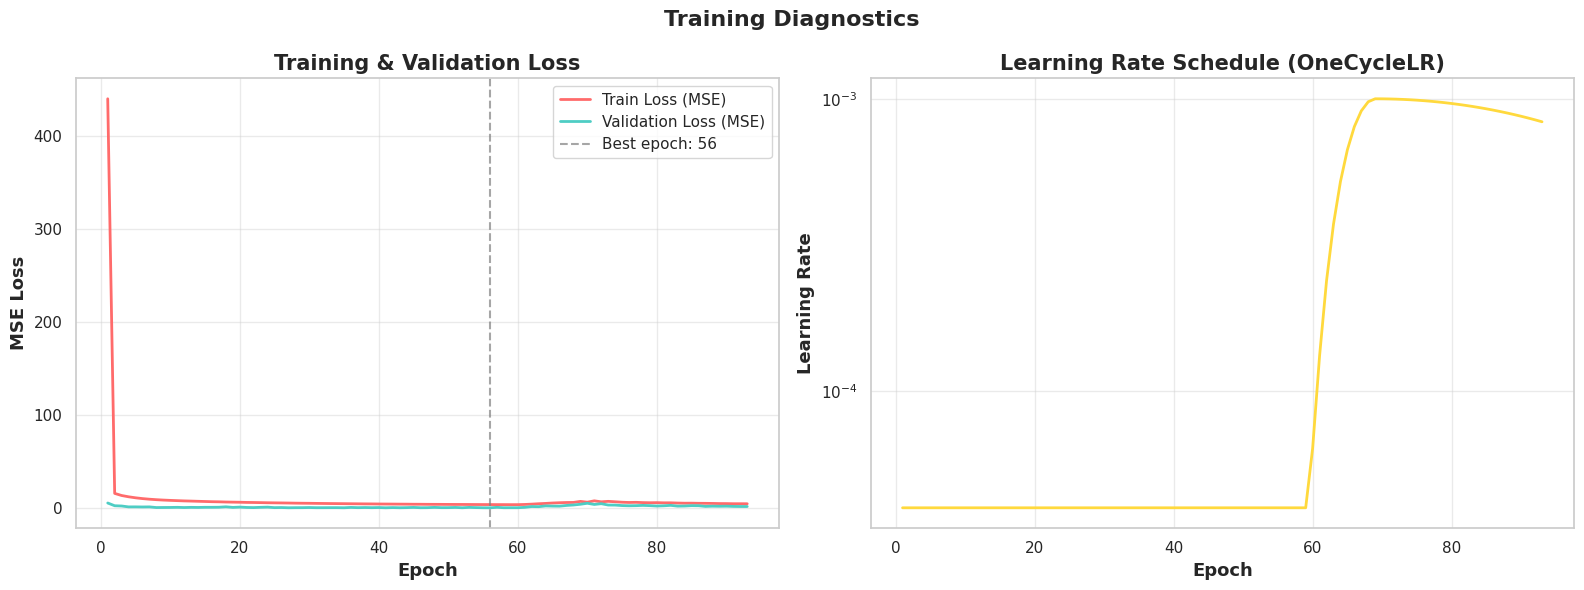

Best Val Loss: 0.5756 at epoch 56
Final Train Loss: 4.9165
Final Val Loss:   1.9656


In [25]:
# ─────────────────────────────────────────────
# SECTION 11: Training Curves
# ─────────────────────────────────────────────
# Note: train_losses / val_losses / learning_rates are either from the
# current run OR loaded from checkpoint — both cases are handled.

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Train vs Val Loss ──
axes[0].plot(epochs_range, train_losses, label='Train Loss (MSE)',
             color='#FF6B6B', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Validation Loss (MSE)',
             color='#4ECDC4', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MSE Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.4)

# Mark best epoch (lowest val loss)
best_epoch = int(val_losses.index(min(val_losses))) + 1
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch}')
axes[0].legend(fontsize=11)

# ── Plot 2: Learning Rate Schedule ──
axes[1].plot(epochs_range, learning_rates, color='#FFD93D', linewidth=2)
axes[1].set_title('Learning Rate Schedule (OneCycleLR)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training Diagnostics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300)
plt.show()

print(f"Best Val Loss: {min(val_losses):.4f} at epoch {best_epoch}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss:   {val_losses[-1]:.4f}")


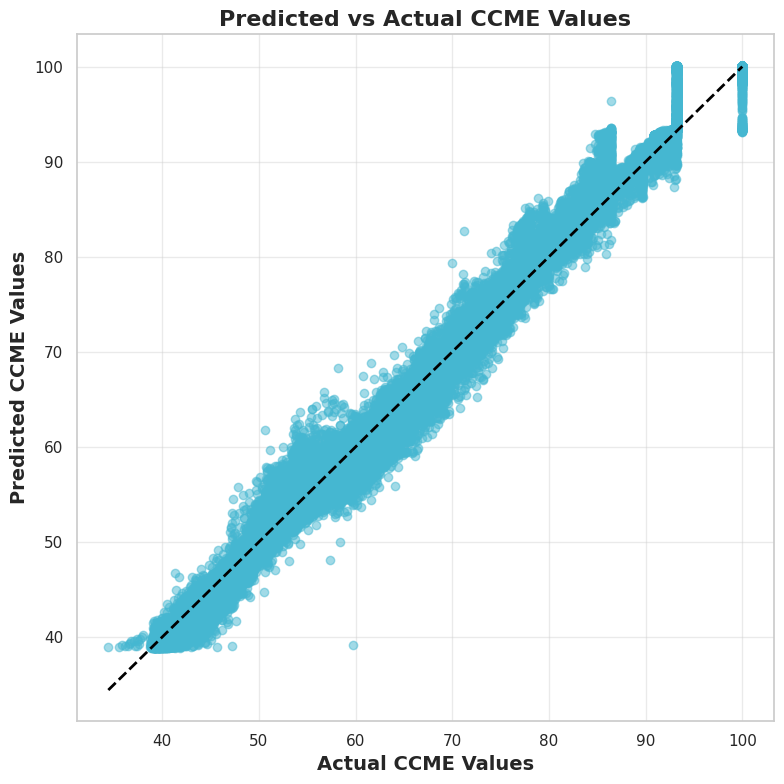

In [26]:

# ─────────────────────────────────────────────
# SECTION 12: Parity Plot (Predicted vs Actual)
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.scatter(t_targets, t_preds, alpha=0.5, color='#45B7D1')
plt.plot([min(t_targets), max(t_targets)], [min(t_targets), max(t_targets)], color='black', linestyle='--', linewidth=2)
plt.title('Predicted vs Actual CCME Values', fontsize=16, fontweight='bold')
plt.xlabel('Actual CCME Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted CCME Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=300)
plt.show()



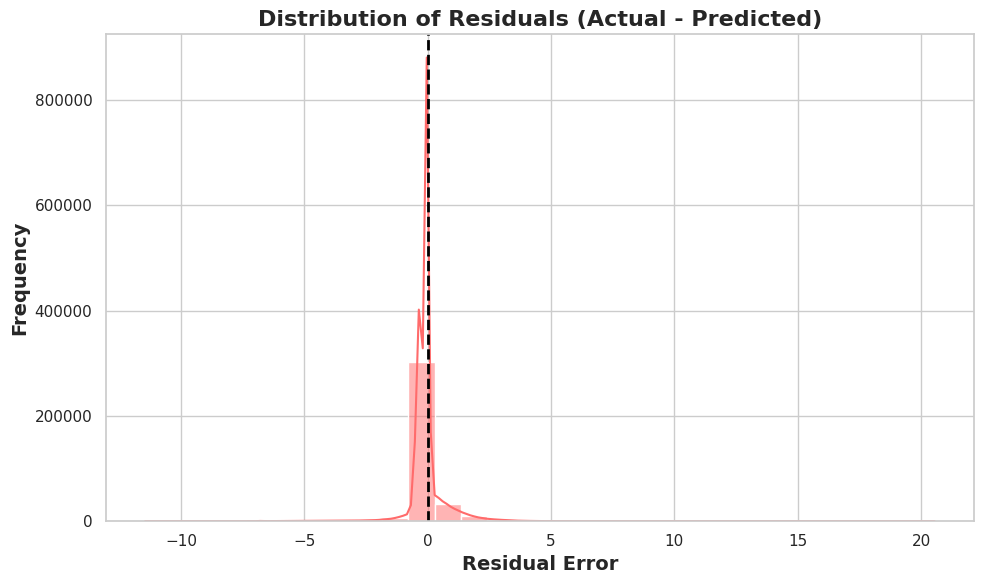

In [27]:

# ─────────────────────────────────────────────
# SECTION 13: Residual Distribution Plot
# ─────────────────────────────────────────────
residuals = t_targets - t_preds

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color="#FF6B6B")
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.title('Distribution of Residuals (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Residual Error', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300)
plt.show()




  REGRESSION METRICS — CCME_Values Prediction
  Metric  Value                                      Description
     MSE 0.5411   Mean Squared Error – average squared deviation
    RMSE 0.7356 Root Mean Squared Error – in original CCME units
     MAE 0.3592 Mean Absolute Error – average absolute deviation
R² Score 0.9980 Coefficient of Determination – 1.0 = perfect fit


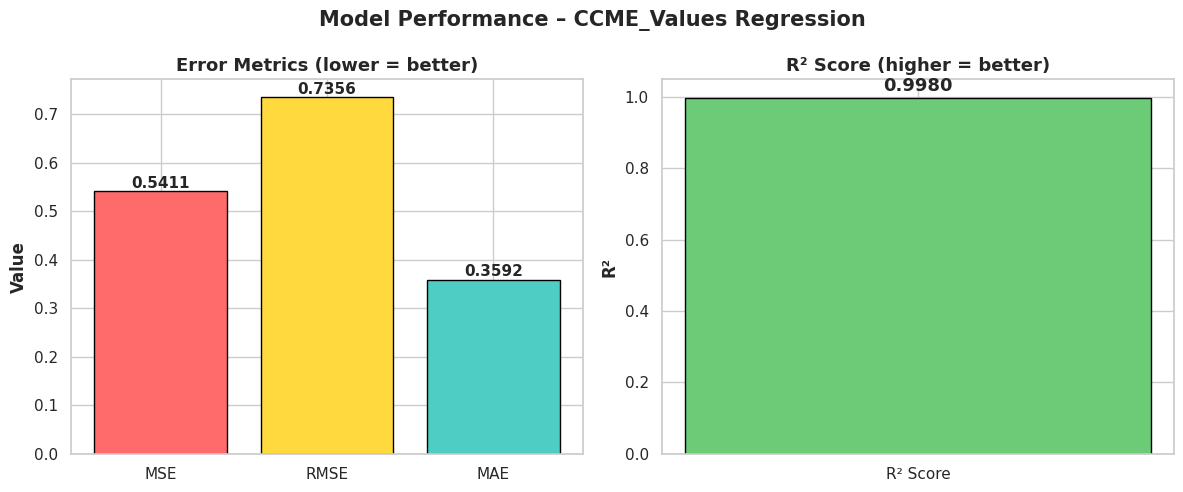

In [28]:
# ─────────────────────────────────────────────
# SECTION 14: Regression Metrics Summary Table
# ─────────────────────────────────────────────
import pandas as pd

metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Value':  [test_mse, test_rmse, test_mae, test_r2],
    'Description': [
        'Mean Squared Error – average squared deviation',
        'Root Mean Squared Error – in original CCME units',
        'Mean Absolute Error – average absolute deviation',
        'Coefficient of Determination – 1.0 = perfect fit'
    ]
})
metrics_df['Value'] = metrics_df['Value'].round(4)

print("\n" + "="*60)
print("  REGRESSION METRICS — CCME_Values Prediction")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

# Visual bar chart of error metrics (lower is better)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

error_names  = ['MSE', 'RMSE', 'MAE']
error_values = [test_mse, test_rmse, test_mae]
axes[0].bar(error_names, error_values, color=['#FF6B6B', '#FFD93D', '#4ECDC4'],
            edgecolor='black')
axes[0].set_title('Error Metrics (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
for i, v in enumerate(error_values):
    axes[0].text(i, v + 0.01 * max(error_values), f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].bar(['R² Score'], [test_r2], color='#6BCB77', edgecolor='black')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('R² Score (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²', fontsize=12, fontweight='bold')
axes[1].text(0, test_r2 + 0.02, f'{test_r2:.4f}', ha='center',
             fontsize=13, fontweight='bold')

plt.suptitle('Model Performance – CCME_Values Regression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=300, bbox_inches='tight')
plt.show()



[XAI] Extracting Attention Rollout Heatmaps...
['Ammonia_mg_l', 'Biochemical_Oxygen_Demand_mg_l', 'Dissolved_Oxygen_mg_l', 'Orthophosphate_mg_l', 'pH_ph_units', 'Temperature_cel', 'Nitrogen_mg_l', 'Nitrate_mg_l', 'Month_sin', 'Month_cos', 'Waterbody_Type_Artificial', 'Waterbody_Type_Coastal_Marine', 'Waterbody_Type_Lake', 'Waterbody_Type_Minor_Waterbodies', 'Waterbody_Type_River', 'Waterbody_Type_Wastewater']


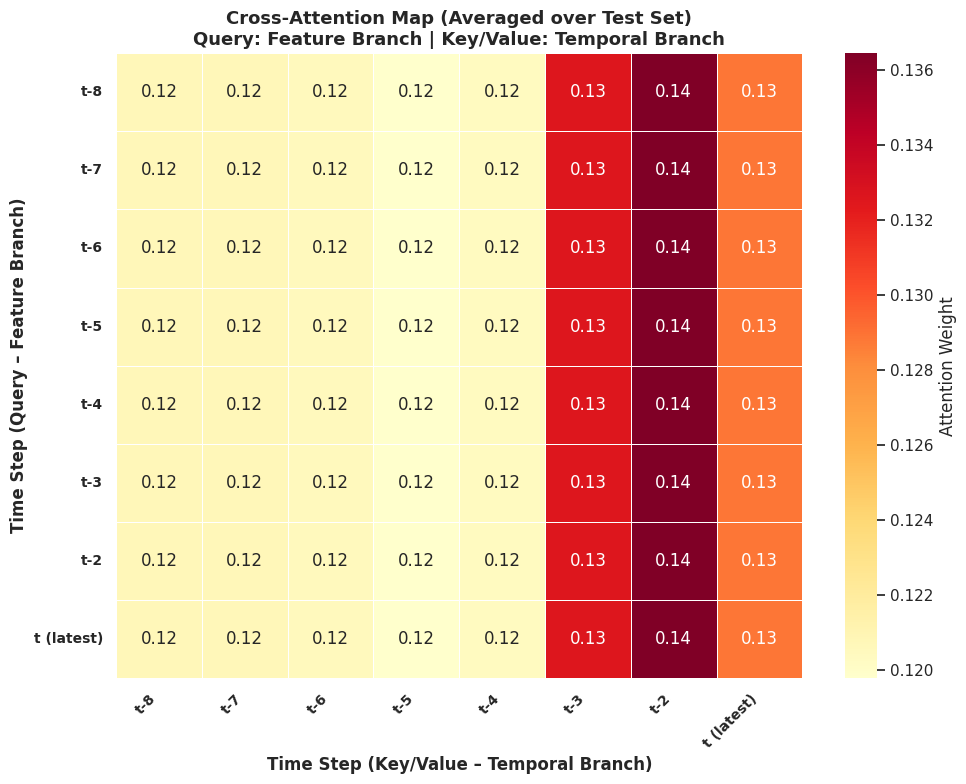

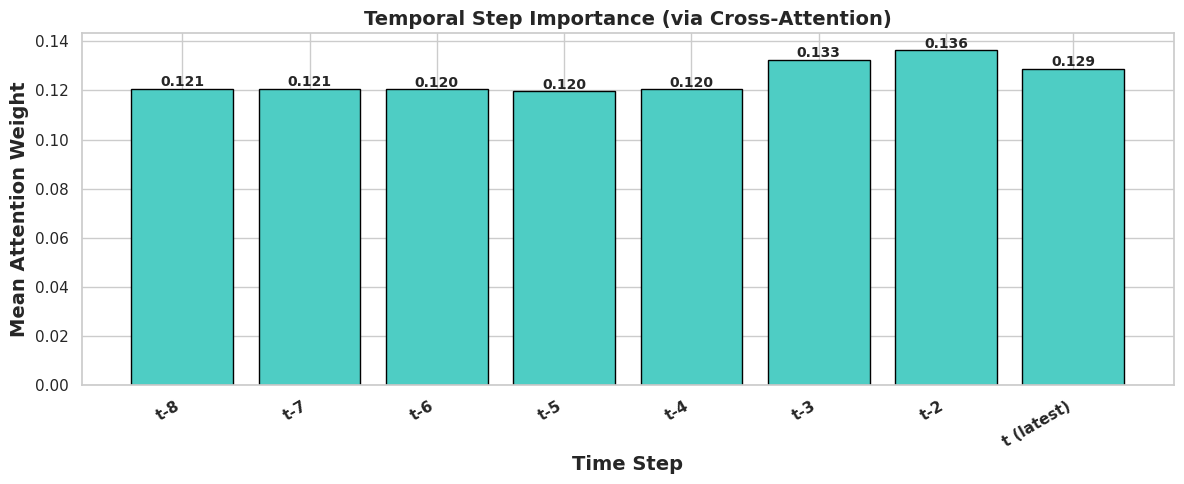

In [29]:
# ─────────────────────────────────────────────
# SECTION 15: XAI – Attention Rollout Heatmap
# ─────────────────────────────────────────────
print("\n[XAI] Extracting Attention Rollout Heatmaps...")
SEQ_LEN = 8
feature_names = X_train.columns.tolist()
print(feature_names)
model.eval()

attn_maps_all = []   # collect over test batches
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        _ = model(batch_x)
        attn_maps_all.append(model.last_attn_weights.cpu().numpy())  # [B, T, T]

attn_maps_all = np.concatenate(attn_maps_all, axis=0)   # [N, T, T]

# Global: mean cross-attention over test set
mean_attn = attn_maps_all.mean(axis=0)    # [T, T]

# ── أسماء خطوات الزمن بدل الأرقام ──
time_step_labels = [f"t-{SEQ_LEN - i}" if i < SEQ_LEN - 1 else "t (latest)"
                    for i in range(SEQ_LEN)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(mean_attn, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Attention Weight'},
            xticklabels=time_step_labels,   # ← أسماء محور X
            yticklabels=time_step_labels)   # ← أسماء محور Y
ax.set_title('Cross-Attention Map (Averaged over Test Set)\n'
             'Query: Feature Branch | Key/Value: Temporal Branch',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time Step (Key/Value – Temporal Branch)', fontsize=12, fontweight='bold')
ax.set_ylabel('Time Step (Query – Feature Branch)',       fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,   fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-time-step importance vector – بأسماء الخطوات
time_importance = mean_attn.mean(axis=0)   # [T]
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(time_step_labels, time_importance, color='#4ECDC4', edgecolor='black')
for bar, val in zip(bars, time_importance):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Time Step', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Attention Weight', fontsize=14, fontweight='bold')
ax.set_title('Temporal Step Importance (via Cross-Attention)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(time_step_labels, rotation=30, ha='right', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()



[XAI] SHAP Gradient Explainer...
shap_values shape after normalization: (50, 8, 16)


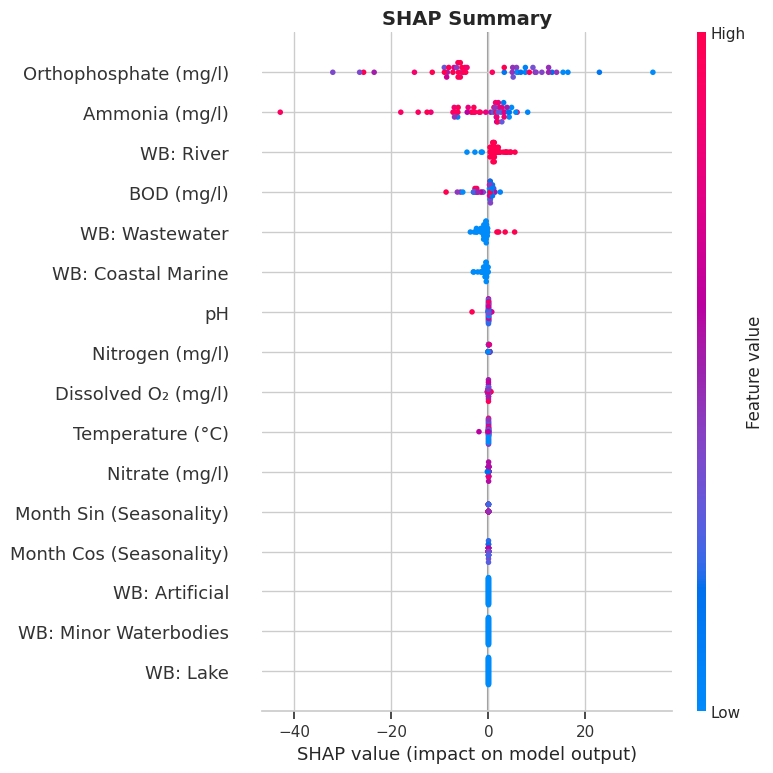

shap_means shape: (16,) | len features: 16


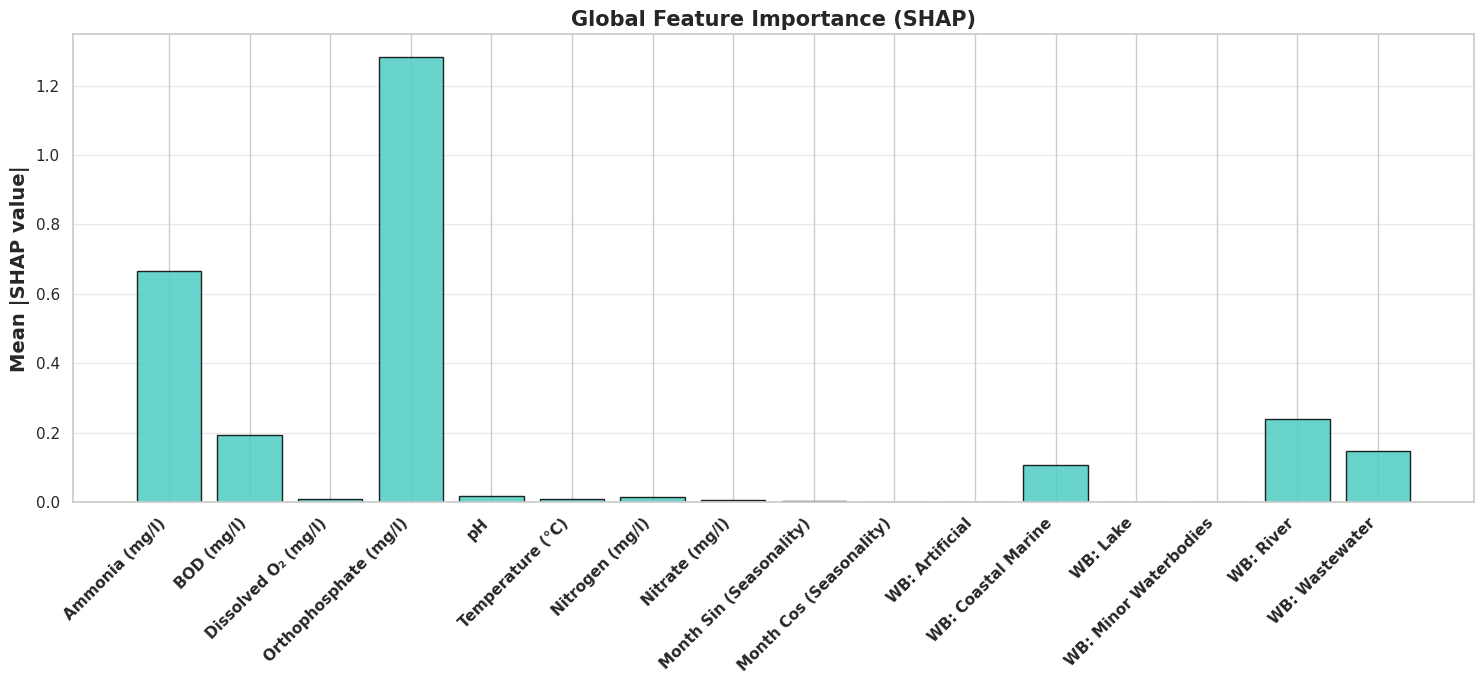

In [30]:

# ─────────────────────────────────────────────
# SECTION 16: XAI – SHAP GradientExplainer
# ─────────────────────────────────────────────
import shap
import numpy as np

print("\n[XAI] SHAP Gradient Explainer...")
background  = X_train_t[:100].to(device)
explainer   = shap.GradientExplainer(model, background)
test_sample = X_test_t[:50]   # already on device

shap_raw = explainer.shap_values(test_sample)

# ──────────────────────────────────────────────────────────────────────
# ✅ ROBUST FIX: Normalize shap_values to shape [N, T, F] regardless of
# what SHAP version returns. Possible raw shapes:
#   • list of [N, T, F]        ← SHAP < 0.40
#   • list of [N, T, F, 1]     ← SHAP 0.40-0.41
#   • ndarray [N, T, F]        ← some versions
#   • ndarray [N, T, F, 1]     ← other versions
# ──────────────────────────────────────────────────────────────────────
def normalize_shap(sv):
    """Always returns a plain float64 ndarray of shape [N, T, F]."""
    # Step 1: unwrap list → take first element (single-output model)
    if isinstance(sv, list):
        sv = sv[0]
    # Step 2: convert to numpy float64 (handles torch tensors too)
    sv = np.asarray(sv, dtype=np.float64)
    # Step 3: squeeze any trailing size-1 dims until we reach 3D [N, T, F]
    while sv.ndim > 3:
        if sv.shape[-1] == 1:
            sv = sv[..., 0]   # drop trailing output-dim
        elif sv.shape[0] == 1:
            sv = sv[0]        # drop leading wrapper-dim
        else:
            break             # unexpected shape — stop and let print below show it
    return sv

shap_values = normalize_shap(shap_raw)
print(f"shap_values shape after normalization: {shap_values.shape}")
# Expected: (50, 8, F)  where F = number of features
assert shap_values.ndim == 3, f"Unexpected SHAP shape: {shap_values.shape}"

# ── Feature name mapping ─────────────────────────────────────────────
raw_feature_names = X_train.columns.tolist()
feature_name_map = {
    'Ammonia_mg_l':                    'Ammonia (mg/l)',
    'Biochemical_Oxygen_Demand_mg_l':  'BOD (mg/l)',
    'Dissolved_Oxygen_mg_l':           'Dissolved O₂ (mg/l)',
    'Orthophosphate_mg_l':             'Orthophosphate (mg/l)',
    'pH_ph_units':                     'pH',
    'Temperature_cel':                 'Temperature (°C)',
    'Nitrogen_mg_l':                   'Nitrogen (mg/l)',
    'Nitrate_mg_l':                    'Nitrate (mg/l)',
    'Month_sin':                       'Month Sin (Seasonality)',
    'Month_cos':                       'Month Cos (Seasonality)',
}
feature_names_display = [
    feature_name_map.get(c, c.replace('_', ' ').replace('Waterbody Type ', 'WB: '))
    for c in raw_feature_names
]

# ── SHAP Summary Plot ────────────────────────────────────────────────
test_np  = test_sample.cpu().numpy()
input_2d = test_np.mean(axis=1)       # [50, T, F] → mean over T → [50, F]
sv_2d    = shap_values.sum(axis=1)    # [50, T, F] → sum  over T → [50, F]

plt.figure(figsize=(11, 7))
shap.summary_plot(sv_2d, input_2d, feature_names=feature_names_display, show=False)
plt.title("SHAP Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Global Feature Importance Bar ───────────────────────────────────
# mean over N (samples) and T (time steps) → 1-D array of shape [F]
shap_means = np.abs(shap_values).mean(axis=(0, 1)).flatten()  # always 1-D ✅
print(f"shap_means shape: {shap_means.shape} | len features: {len(feature_names_display)}")

fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(feature_names_display))
ax.bar(x, shap_means, color='#4ECDC4', edgecolor='black', alpha=0.85)

ax.set_ylabel('Mean |SHAP value|', fontsize=14, fontweight='bold')
ax.set_title('Global Feature Importance (SHAP)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_names_display, rotation=45, ha='right',
                   fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('global_feature_importance_shap.png', dpi=300, bbox_inches='tight')
plt.show()


In [31]:

# ─────────────────────────────────────────────
# SECTION 17: XAI – Local Explanation Report
# ─────────────────────────────────────────────
print("\n[XAI] Local Explanations (5 test samples):")
print("="*80)

for sample_idx in range(5):
    true_val = t_targets[sample_idx]
    pred_val = t_preds[sample_idx]

    # Feature importance summed across time
    sv = shap_values[sample_idx]         # [T, F]
    sv_sum = sv.sum(axis=0)              # [F]
    top_k  = np.argsort(np.abs(sv_sum))[::-1][:3] # top-3

    top_feats = [(feature_names_display[i], sv_sum[i]) for i in top_k]
    feat_str  = ", ".join([f"{n}({'↑' if v > 0 else '↓'}{abs(v):.3f})"
                           for n, v in top_feats])

    print(f"Sample {sample_idx+1}: True CCME={true_val:.2f} | Pred={pred_val:.2f}")
    print(f"   → Key drivers: {feat_str}\n")




[XAI] Local Explanations (5 test samples):
Sample 1: True CCME=89.63 | Pred=89.80
   → Key drivers: Orthophosphate (mg/l)(↑6.663), Ammonia (mg/l)(↑3.230), BOD (mg/l)(↑0.903)

Sample 2: True CCME=89.63 | Pred=89.90
   → Key drivers: Orthophosphate (mg/l)(↑3.260), Ammonia (mg/l)(↑2.718), WB: River(↑0.928)

Sample 3: True CCME=74.34 | Pred=73.94
   → Key drivers: Orthophosphate (mg/l)(↓5.551), Ammonia (mg/l)(↑2.037), WB: River(↑0.988)

Sample 4: True CCME=71.68 | Pred=71.56
   → Key drivers: Orthophosphate (mg/l)(↓9.109), Ammonia (mg/l)(↑5.903), BOD (mg/l)(↓1.292)

Sample 5: True CCME=71.74 | Pred=74.37
   → Key drivers: Orthophosphate (mg/l)(↓6.564), Ammonia (mg/l)(↑2.199), WB: River(↑1.215)



In [32]:

# ─────────────────────────────────────────────
# SECTION 18: DiCE – Counterfactual Explanations
# ─────────────────────────────────────────────
# DiCE for Regression is possible but requires different parameters.
# Disabled for now.
print("\n[DiCE] Disabled for regression.")




[DiCE] Disabled for regression.



ABLATION STUDY
  [Feature Branch Only]  RMSE=7.0532  MAE=4.4121
  [Temporal Branch Only]  RMSE=2.1675  MAE=1.2130
  [Full Dual-Branch]  RMSE=1.9247  MAE=1.1445


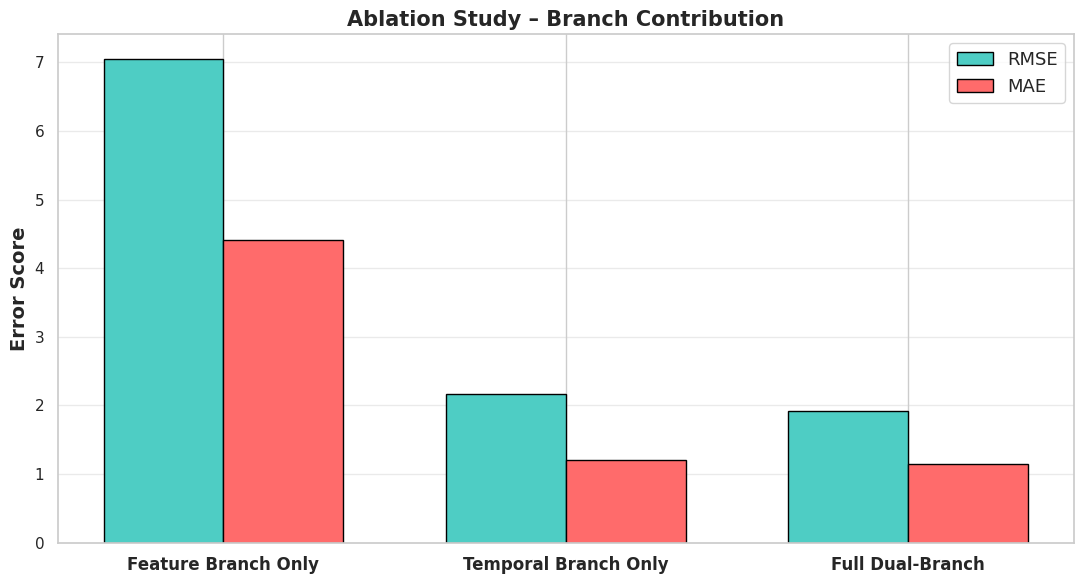

In [ ]:
# ─────────────────────────────────────────────
# SECTION 19: Ablation Study
# ─────────────────────────────────────────────
print("\n" + "="*80)
print("ABLATION STUDY")
print("="*80)


class AblationModel(nn.Module):
    def __init__(self, input_dim, d_model=128, n_heads=4,
                 feat_layers=2, temp_layers=2,
                 output_dim=1, dropout=0.15,
                 use_feature_branch=True,
                 use_temporal_branch=True):
        super().__init__()
        self.use_feat = use_feature_branch
        self.use_temp = use_temporal_branch
        self.d_model  = d_model

        if use_feature_branch:
            self.feat_embed       = FeatureEmbedding(input_dim, d_model)
            self.feat_transformer = FeatureTransformer(d_model, n_heads, feat_layers, dropout)

        if use_temporal_branch:
            self.temp_transformer = TemporalTransformer(input_dim, d_model, n_heads, temp_layers, dropout)

        if use_feature_branch and use_temporal_branch:
            self.cross_attn = CrossAttentionFusion(d_model, n_heads, dropout)

        self.pool      = nn.AdaptiveAvgPool1d(1)
        self.regressor = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, output_dim)
        )

    def forward(self, x):
        if self.use_feat and self.use_temp:
            feat_emb = self.feat_embed(x)
            feat_out = self.feat_transformer(feat_emb)
            temp_out = self.temp_transformer(x)
            fused, _ = self.cross_attn(feat_out, temp_out)
        elif self.use_feat:
            feat_emb = self.feat_embed(x)
            fused    = self.feat_transformer(feat_emb)
        else:
            fused = self.temp_transformer(x)

        fused  = fused.transpose(1, 2)
        pooled = self.pool(fused).squeeze(-1)
        return self.regressor(pooled)


def quick_train_eval(model_v, name, epochs=30):
    opt  = optim.AdamW(model_v.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.MSELoss()

    for ep in range(epochs):
        model_v.train()
        for bx, by in train_loader:
            bx = bx.to(device); by = by.to(device)
            loss = crit(model_v(bx), by)
            opt.zero_grad(); loss.backward(); opt.step()

    model_v.eval()
    preds_all, targs_all = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            preds_all.extend(model_v(bx).cpu().numpy().flatten())
            targs_all.extend(by.cpu().numpy().flatten())

    rmse = np.sqrt(mean_squared_error(targs_all, preds_all))
    mae  = mean_absolute_error(targs_all, preds_all)
    print(f"  [{name}]  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return rmse, mae


configs = [
    ("Feature Branch Only",  True,  False),
    ("Temporal Branch Only", False, True),
    ("Full Dual-Branch",     True,  True),
]

ablation_results = {}
for name, uf, ut in configs:
    m_abl = AblationModel(input_size, d_model=128, n_heads=4,
                          feat_layers=2, temp_layers=2,
                          output_dim=1,
                          use_feature_branch=uf,
                          use_temporal_branch=ut).to(device)
    rmse, mae = quick_train_eval(m_abl, name, epochs=4)
    ablation_results[name] = {'RMSE': rmse, 'MAE': mae}

labels    = list(ablation_results.keys())https://www.sciencedirect.com/science/article/pii/S2589914725001744
rmse_vals = [ablation_results[k]['RMSE'] for k in labels]
mae_vals  = [ablation_results[k]['MAE']  for k in labels]

x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w/2, rmse_vals, w, label='RMSE', color='#4ECDC4', edgecolor='black')
ax.bar(x + w/2, mae_vals,  w, label='MAE',  color='#FF6B6B', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.set_ylabel('Error Score', fontsize=14, fontweight='bold')
ax.set_title('Ablation Study – Branch Contribution', fontsize=15, fontweight='bold')
ax.legend(fontsize=13); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=300, bbox_inches='tight')
plt.show()


In [34]:

# ─────────────────────────────────────────────
# SECTION 20: Final Summary
# ─────────────────────────────────────────────
print("\n" + "="*80)
print(" FINAL MODEL PERFORMANCE SUMMARY – Dual-Branch Regression")
print("="*80)
print(f"  Test MSE:   {test_mse:>8.4f}")
print(f"  Test RMSE:  {test_rmse:>8.4f}")
print(f"  Test MAE:   {test_mae:>8.4f}")
print(f"  R2 Score:   {test_r2:>8.4f}")
print("="*80)




 FINAL MODEL PERFORMANCE SUMMARY – Dual-Branch Regression
  Test MSE:     0.5411
  Test RMSE:    0.7356
  Test MAE:     0.3592
  R2 Score:     0.9980


In [35]:
# End of notebook — Dual-Branch Transformer Regression on CCME_Values
